In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # .. from notebooks/
sys.path.insert(0, str(repo_root))      # make the repo importable

import pairs
print(pairs.__file__)


/Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs/__init__.py


In [2]:
# From notebooks/ → install the package from the repo root (one level up)
%pip install -e "..[notebooks]"  # or just ".." if you didn’t define the [notebooks] extra

Obtaining file:///Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading


  Installing build dependencies ... -

 \

 | done


  Checking if build backend supports build_editable ... done


...

  Building editable for pairs-trading (pyproject.toml) ... -

 done
  Created wheel for pairs-trading: filename=pairs_trading-0.1.0-0.editable-py3-none-any.whl size=17638 sha256=4ff77159c80d21892b26ef75de250f9a9e99546e0f680d18adec687e7752de1e
  Stored in directory: /private/var/folders/2r/5z_b14md2nn8qlbhb80cwbh80000gn/T/pip-ephem-wheel-cache-lmp1r88q/wheels/38/2e/3b/2829dadc9aa5c128d8225d82450d35888645b2772da709279e
Successfully built pairs-trading


  Attempting uninstall: pairs-trading
    Found existing installation: pairs-trading 0.1.0
    Uninstalling pairs-trading-0.1.0:


      Successfully uninstalled pairs-trading-0.1.0


Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys, importlib.util
print(sys.executable)
print(importlib.util.find_spec("pairs"))
import pairs
print(pairs.__version__)
print(pairs.__file__)

/Users/mengren/anaconda3/envs/stat-arb/bin/python
ModuleSpec(name='pairs', loader=<_frozen_importlib_external.SourceFileLoader object at 0x107ea5250>, origin='/Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs/__init__.py', submodule_search_locations=['/Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs'])
0.1.0
/Users/mengren/Documents/projects/coding_finance/dynamic-hedge-pairs-trading/pairs/__init__.py


# 1. Download historical data using openbb

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# In a notebook under notebooks/
from pairs import load_universe

tickers = load_universe("spx_ndx_combined")  # returns a pandas.Index (UPPERCASE, deduped)
# tickers = load_universe("ndx")
print(len(tickers), tickers[:10].tolist())   # quick peek


517 ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']


In [6]:
from pairs import load_prices, download_openbb

In [7]:
start_date="2020-01-01"
end_date="2025-01-01"

# df, failed = download_openbb(tickers, start_date, end_date, return_failed=True)
df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)

# print(df_train.head())
if failed:
    print("No data for:", failed)

Download:   0%|          | 0/517 [00:00<?, ?it/s]

A:   0%|          | 0/517 [00:00<?, ?it/s]       

A:   0%|          | 1/517 [00:00<06:55,  1.24it/s]

AAPL:   0%|          | 1/517 [00:00<06:55,  1.24it/s]

AAPL:   0%|          | 2/517 [00:01<04:41,  1.83it/s]

...

ZS: 100%|█████████▉| 516/517 [02:52<00:00,  3.53it/s]

ZTS: 100%|█████████▉| 516/517 [02:52<00:00,  3.53it/s]

ZTS: 100%|██████████| 517/517 [02:53<00:00,  3.45it/s]

ZTS: 100%|██████████| 517/517 [02:53<00:00,  2.98it/s]

No data for: ['AVB', 'BK', 'CTRA', 'DAY', 'EA', 'EQR', 'FI', 'HOLX', 'IPG', 'K', 'MMC', 'WBA']


In [8]:
df_train

open        high         low       close   volume  \
ticker datetime                                                              
A      2020-01-02   85.900002   86.349998   85.199997   85.949997  1410500   
       2020-01-03   84.669998   85.330002   84.500000   84.570000  1118300   
       2020-01-06   84.000000   84.820000   83.599998   84.820000  1993200   
       2020-01-07   83.959999   85.260002   83.940002   85.080002  1684700   
       2020-01-08   85.959999   86.470001   85.199997   85.919998  1847600   
...                       ...         ...         ...         ...      ...   
ZTS    2024-12-24  163.699997  165.039993  162.740005  164.699997  1023600   
       2024-12-26  163.720001  165.789993  163.020004  165.520004  2167200   
       2024-12-27  164.949997  166.529999  163.520004  164.600006  1800100   
       2024-12-30  163.889999  164.050003  161.449997  162.240005  1531400   
       2024-12-31  162.899994  163.750000  161.869995  162.929993  1327400   

                   dividend  split_ratio  
ticker datetime                           
A      2020-01-02       0.0          NaN  
       2020-01-03       0.0          NaN  
       2020-01-06       0.0          NaN  
       2020-01-07       0.0          NaN  
       2020-01-08       0.0          NaN  
...                     ...          ...  
ZTS    2024-12-24       0.0          NaN  
       2024-12-26       0.0          NaN  
       2024-12-27       0.0          NaN  
       2024-12-30       0.0          NaN  
       2024-12-31       0.0          NaN  

[626750 rows x 7 columns]

## 1.1 Pre-filter for Data Quality

We keep tickers whose coverage matches the global coverage

In [9]:
import pandas as pd

# infer level names/positions
lvl_names = list(df_train.index.names)
ticker_lvl = 0                                  # you said ticker is first level
time_lvl_name = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

# global time span
full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

# per-ticker start/end
starts = df_train.groupby(level=ticker_lvl).apply(
    lambda g: g.index.get_level_values(time_lvl_name).min()
)
ends = df_train.groupby(level=ticker_lvl).apply(
    lambda g: g.index.get_level_values(time_lvl_name).max()
)

# tickers whose coverage matches the global coverage
tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index

# filter df by those tickers
df_filtered = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

The original number of tickers, *vs.* the number of tickers matching the global coverage

In [10]:
len(df_train.index.get_level_values('ticker').unique()), len(df_filtered.index.get_level_values('ticker').unique())

(505, 488)

Below is the set of tickers whose time coverages are shorter than the global coverage

In [11]:
set(tickers) - set(df_filtered.index.get_level_values('ticker').unique())

{'ABNB',
 'APP',
 'ARM',
 'AVB',
 'BK',
 'CARR',
 'CEG',
 'COIN',
 'CTRA',
 'DASH',
 'DAY',
 'EA',
 'EQR',
 'EXE',
 'FI',
 'GEHC',
 'GEV',
 'GFS',
 'HOLX',
 'IPG',
 'K',
 'KVUE',
 'MMC',
 'OTIS',
 'PARA',
 'PLTR',
 'SOLV',
 'VLTO',
 'WBA'}

# 2. Cointegration Screening

## 2.1 Initial Cointegration Screening

Here, we implement the following two cointegration tests
- Engle-Granger test, and
- Johansen test

In [12]:
from pairs import find_cointegrated_pairs_dualgate

summary_dual = find_cointegrated_pairs_dualgate(
    df_filtered,
    alpha_eg=0.05, eg_trend="c",
    alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
    n_workers=16, chunksize=8, show_progress=True
)

Dual-gate cointegration (EG + Johansen):   0%|          | 0/118828 [00:00<?, ?it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1081/118828 [00:00<00:29, 3929.84it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1474/118828 [00:00<01:23, 1404.68it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1673/118828 [00:01<01:47, 1085.58it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 1807/118828 [00:01<02:04, 936.88it/s] 

...

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118513/118828 [03:43<00:00, 524.44it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118566/118828 [03:43<00:00, 490.49it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118616/118828 [03:44<00:00, 473.88it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118697/118828 [03:44<00:00, 556.64it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118754/118828 [03:44<00:00, 543.50it/s]

In [13]:
summary_dual.sample(20)

,,eg_t,eg_p,eg_p_fdr,eg_pass,joh_stat,joh_pass,verdict
ticker1,ticker2,,,,,,,
PEP,STLD,-2.890002,0.138720,0.823406,False,9.034961,False,fail
CFG,DELL,-2.044868,0.505190,0.967987,False,7.674823,False,fail
ISRG,RTX,-2.034444,0.510633,0.969155,False,8.335380,False,fail
ABT,DDOG,-3.822102,0.012663,0.417643,False,21.700607,True,fail
BKNG,INCY,-1.028020,0.897403,1.000000,False,9.751483,False,fail
HSIC,MU,-2.872344,0.143748,0.829731,False,12.709152,False,fail
CBRE,HRL,-1.936230,0.561525,0.977144,False,6.262806,False,fail
MRK,WBD,-3.086581,0.091030,0.751643,False,10.950374,False,fail
MAA,TRI,-1.503408,0.759883,1.000000,False,4.998303,False,fail


In [14]:
# summary_dual is what find_cointegrated_pairs_dualgate returns
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
# normalize to [0,1] and average
tmp["pre_score"] = 0.5*(tmp["rank_eg"]/tmp["rank_eg"].max()
                      + tmp["rank_joh"]/tmp["rank_joh"].max())
prelim = tmp.sort_values("pre_score", ascending=True)   # lower rank is better
# pick top N (e.g., 2–3× the number you intend to trade)
candidates = prelim.head(200).index.to_list()

## 2.1.1 Multiple Testing Correction (Benjamini-Hochberg FDR)

### Why it matters

We just tested **121,771 pairs** simultaneously at α = 0.05.  
By chance alone, we expect ~6,089 false positives even if *no pair* is truly cointegrated.

The **Benjamini-Hochberg (BH)** procedure controls the *False Discovery Rate* (FDR) — the expected fraction of declared discoveries that are false — at level α, which is much less conservative than Bonferroni while still being meaningful.

The new `eg_p_fdr` column in `summary_dual` contains the BH-adjusted p-value for each pair.  
`find_cointegrated_pairs_dualgate` already runs BH by default (`fdr_method="bh"`), but we can also apply it post-hoc to the existing `summary_dual` for transparency.

In [15]:
import numpy as np
from pairs.stats.cointegration import benjamini_hochberg_fdr

# ── Post-hoc BH correction on summary_dual ──────────────────────────────────
alpha_fdr = 0.05
raw_pvals = summary_dual["eg_p"].values

reject_bh, padj = benjamini_hochberg_fdr(raw_pvals, alpha=alpha_fdr)

summary_dual_fdr = summary_dual.copy()
summary_dual_fdr["eg_p_fdr"] = padj
summary_dual_fdr["eg_pass_fdr"] = reject_bh   # BH-corrected gate

n_raw   = int((raw_pvals <= alpha_fdr).sum())
n_fdr   = int(reject_bh.sum())
n_tests = len(raw_pvals)

print(f"Total pairs tested        : {n_tests:>8,}")
print(f"Expected false positives  : {n_tests * alpha_fdr:>8,.0f}  (= {n_tests} × {alpha_fdr})")
print(f"Raw EG significant (p≤.05): {n_raw:>8,}")
print(f"After BH correction       : {n_fdr:>8,}  ({n_raw - n_fdr:+d} removed)")
print()
print("Head of BH-corrected EG results (sorted by adj p-value):")
summary_dual_fdr[summary_dual_fdr["eg_pass_fdr"]].sort_values("eg_p_fdr").head(10)[
    ["eg_t", "eg_p", "eg_p_fdr", "eg_pass_fdr", "joh_pass", "verdict"]
]

Total pairs tested        :  118,828
Expected false positives  :    5,941  (= 118828 × 0.05)
Raw EG significant (p≤.05):    8,844
After BH correction       :      304  (+8540 removed)

Head of BH-corrected EG results (sorted by adj p-value):


eg_t          eg_p  eg_p_fdr  eg_pass_fdr  joh_pass  \
ticker1 ticker2                                                            
CCL     SHOP    -6.470849  1.466481e-07  0.005850         True      True   
NCLH    SHOP    -6.510805  1.189120e-07  0.005850         True      True   
        TTWO    -6.371451  2.461515e-07  0.005850         True      True   
        XYZ     -6.468029  1.488290e-07  0.005850         True      True   
        ZBRA    -6.410423  2.010411e-07  0.005850         True      True   
CCL     TTWO    -6.250168  4.597262e-07  0.006247         True      True   
NCLH    PNC     -6.230421  5.085499e-07  0.006247         True      True   
        TRMB    -6.266599  4.226243e-07  0.006247         True      True   
        TROW    -6.223924  5.256942e-07  0.006247         True      True   
        WDAY    -6.298250  3.592284e-07  0.006247         True      True   

                verdict  
ticker1 ticker2          
CCL     SHOP       pass  
NCLH    SHOP       pass  
        TTWO       pass  
        XYZ        pass  
        ZBRA       pass  
CCL     TTWO       pass  
NCLH    PNC        pass  
        TRMB       pass  
        TROW       pass  
        WDAY       pass

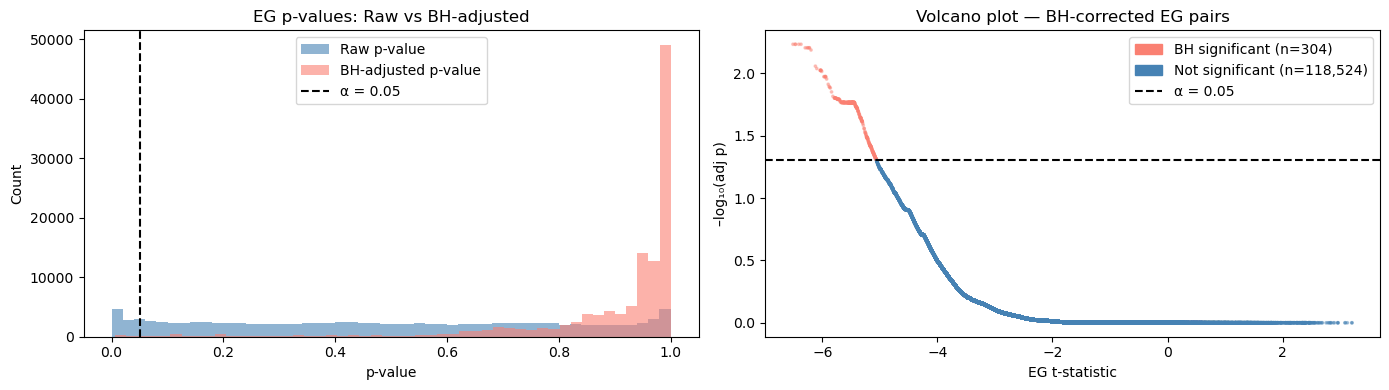


Conclusion: BH removes 8,540 of 8,844 raw-significant pairs, keeping 304 with controlled FDR ≤ 5%.


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left: histogram of raw vs BH-adjusted p-values ──────────────────────────
ax = axes[0]
ax.hist(raw_pvals, bins=50, alpha=0.6, label="Raw p-value", color="steelblue")
ax.hist(padj, bins=50, alpha=0.6, label="BH-adjusted p-value", color="salmon")
ax.axvline(alpha_fdr, color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("p-value")
ax.set_ylabel("Count")
ax.set_title("EG p-values: Raw vs BH-adjusted")
ax.legend()

# ── Right: volcano-style scatter (t-stat vs –log10 adj p) ───────────────────
ax = axes[1]
log_padj = -np.log10(np.clip(padj, 1e-300, 1.0))
colours = np.where(reject_bh, "salmon", "steelblue")
ax.scatter(summary_dual["eg_t"].values, log_padj, c=colours, s=3, alpha=0.4)
ax.axhline(-np.log10(alpha_fdr), color="black", linestyle="--", lw=1.5,
           label=f"BH threshold (α={alpha_fdr})")
ax.set_xlabel("EG t-statistic")
ax.set_ylabel("–log₁₀(adj p)")
ax.set_title("Volcano plot — BH-corrected EG pairs")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="salmon", label=f"BH significant (n={n_fdr:,})"),
    Patch(color="steelblue", label=f"Not significant (n={n_tests - n_fdr:,})"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"α = {alpha_fdr}"),
])

plt.tight_layout()
plt.show()
print(f"\nConclusion: BH removes {n_raw - n_fdr:,} of {n_raw:,} raw-significant pairs, "
      f"keeping {n_fdr:,} with controlled FDR ≤ {alpha_fdr:.0%}.")

In [17]:
prelim

eg_t          eg_p  eg_p_fdr  eg_pass   joh_stat  \
ticker1 ticker2                                                         
CCL     TTWO    -6.250168  4.597262e-07  0.006247     True  42.250921   
NCLH    TTWO    -6.371451  2.461515e-07  0.005850     True  39.980485   
        NSC     -6.121224  8.850157e-07  0.008764     True  38.021322   
        TRMB    -6.266599  4.226243e-07  0.006247     True  37.178857   
CCL     SHOP    -6.470849  1.466481e-07  0.005850     True  36.676596   
...                   ...           ...       ...      ...        ...   
AVGO    MPC      0.806872  9.938628e-01  1.000000    False   2.467877   
AXP     OXY      0.582827  9.931300e-01  1.000000    False   1.660159   
AVGO    COP      1.076664  1.000000e+00  1.000000    False   2.797799   
AMP     DVN      0.945155  1.000000e+00  1.000000    False   2.757229   
KKR     OXY      0.944967  1.000000e+00  1.000000    False   2.508216   

                 joh_pass verdict   rank_eg  rank_joh  pre_score  
ticker1 ticker2                                                   
CCL     TTWO         True    pass       8.0      11.0   0.000080  
NCLH    TTWO         True    pass       5.0      21.0   0.000109  
        NSC          True    pass      12.0      36.0   0.000202  
        TRMB         True    pass       7.0      48.0   0.000232  
CCL     SHOP         True    pass       2.0      56.0   0.000244  
...                   ...     ...       ...       ...        ...  
AVGO    MPC         False    fail  117696.0  118369.0   0.995299  
AXP     OXY         False    fail  117287.0  118786.0   0.995326  
AVGO    COP         False    fail  118351.5  117875.0   0.995990  
AMP     DVN         False    fail  118351.5  117956.0   0.996331  
KKR     OXY         False    fail  118351.5  118320.0   0.997862  

[118828 rows x 10 columns]

In [18]:
candidates

[('CCL', 'TTWO'),
 ('NCLH', 'TTWO'),
 ('NCLH', 'NSC'),
 ('NCLH', 'TRMB'),
 ('CCL', 'SHOP'),
 ('NCLH', 'WDAY'),
 ('NCLH', 'PDD'),
 ('NCLH', 'TER'),
 ('NCLH', 'TXN'),
 ('NCLH', 'SBUX'),
 ('NCLH', 'SHOP'),
 ('CCL', 'EBAY'),
 ('ABT', 'NSC'),
 ('NCLH', 'UDR'),
 ('NCLH', 'TDY'),
 ('CCL', 'COO'),
 ('NCLH', 'ZS'),
 ('CCL', 'TRMB'),
 ('NCLH', 'SW'),
 ('NCLH', 'PPG'),
 ('NCLH', 'ZBRA'),
 ('CCL', 'MELI'),
 ('CCL', 'ECL'),
 ('NCLH', 'WEC'),
 ('NCLH', 'ROK'),
 ('NCLH', 'TROW'),
 ('CCL', 'CTSH'),
 ('NCLH', 'STT'),
 ('CCL', 'TYL'),
 ('CCL', 'FDX'),
 ('NCLH', 'TEL'),
 ('NCLH', 'NWSA'),
 ('NCLH', 'VRSN'),
 ('NCLH', 'PNW'),
 ('CCL', 'TER'),
 ('NCLH', 'TEAM'),
 ('GM', 'SW'),
 ('NCLH', 'XYZ'),
 ('CCL', 'GM'),
 ('NCLH', 'UNP'),
 ('CCL', 'WDAY'),
 ('NCLH', 'NDSN'),
 ('NCLH', 'PODD'),
 ('NCLH', 'TTD'),
 ('CCL', 'PDD'),
 ('NCLH', 'TYL'),
 ('CCL', 'EXPE'),
 ('MA', 'PH'),
 ('CCL', 'EMN'),
 ('NCLH', 'XEL'),
 ('CCL', 'SW'),
 ('RCL', 'WMT'),
 ('NCLH', 'POOL'),
 ('CCL', 'ZBRA'),
 ('NCLH', 'UBER'),
 ('CCL', 'NFLX'),

## 2.2 Kalman Filtering and Stationarity Tests on Residuals

In [19]:
from pairs import (
    fit_kalman_hedge,
    summarize_spread_stationarity_joblib,
)

### Overview: Dynamic Hedge via Kalman Filter

We model a time-varying hedge ratio between two assets with a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = 
\begin{bmatrix}
\beta_t \\ \alpha_t
\end{bmatrix},
\qquad
\theta_t = \theta_{t-1} + w_t
$$
where $w_t\sim\mathcal{N}(0, Q)$.

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t,
\qquad
v_t\sim\mathcal{N}(0, R).
$$

**Calibration:**
Expectation-Maximization (EM) can learn $Q$ (state noise) and $R$ (observation noise).



### Terminology

- **In-sample calibration** (often called "training"): learn $Q$, $R$ with EM and estiamte $(\alpha_t, \beta_t)$ on the train window.
- **Out-of-sample continuation**: continue **filtering** on the test window using the **last train state and learng $Q, R$.

Here, we perform in-sample calibration of a Kalman filter in the cell below.

In [20]:
# in-sample calibration of a Kalman filter
states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="filter",   # causal: the smoother would let each state see the future
    em_iters=5,          # modest EM to learn Q/R
    q=1e-5,              # slow drift
    n_workers=None,      # all CPUs
    chunksize=100,
    show_progress=True,
    return_params=True,  # ← get (states, params)
)

Kalman (α_t, β_t):   0%|          | 0/200 [00:00<?, ?it/s]

Kalman (α_t, β_t):   1%|          | 2/200 [00:04<07:47,  2.36s/it]

Kalman (α_t, β_t):   4%|▍         | 8/200 [00:04<01:28,  2.17it/s]

Kalman (α_t, β_t):  13%|█▎        | 26/200 [00:04<00:18,  9.17it/s]

Kalman (α_t, β_t):  17%|█▋        | 34/200 [00:06<00:21,  7.61it/s]

...

Kalman (α_t, β_t):  93%|█████████▎| 186/200 [00:19<00:01, 13.03it/s]

Kalman (α_t, β_t):  94%|█████████▍| 189/200 [00:20<00:00, 15.47it/s]

Kalman (α_t, β_t):  96%|█████████▌| 192/200 [00:20<00:00, 12.18it/s]

Kalman (α_t, β_t):  97%|█████████▋| 194/200 [00:20<00:00,  9.44it/s]

Kalman (α_t, β_t): 100%|█████████▉| 199/200 [00:20<00:00, 13.98it/s]

In [21]:
summary_stationarity = summarize_spread_stationarity_joblib(states_tr, alpha=0.05, regression="c", 
                                                            chunksize=256, show_progress=True)

Testing stationarity:   0%|          | 0/200 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/200 [00:01<02:01,  1.63it/s]

Testing stationarity:  16%|█▌        | 31/200 [00:01<00:05, 31.63it/s]

Testing stationarity:  40%|████      | 80/200 [00:01<00:01, 90.75it/s]

Testing stationarity:  64%|██████▍   | 128/200 [00:01<00:00, 150.92it/s]

Testing stationarity:  90%|████████▉ | 179/200 [00:01<00:00, 215.87it/s]

In [22]:
summary_stationarity

adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZBH     -25.413761  0.000000e+00   0.614125  0.021352  0.610654   
        VICI    -11.813433  8.750673e-22   0.653714  0.017753  1.612253   
CCL     NWS      -9.392558  6.501977e-16   0.782534  0.010000  2.169211   
        NWSA     -9.134549  2.959846e-15   0.801419  0.010000  2.323243   
NCLH    PPG      -8.932499  9.729622e-15   0.559284  0.028314  0.753319   
...                    ...           ...        ...       ...       ...   
        PDD      -5.523494  1.854898e-06   0.363709  0.092798  1.818269   
        ROL      -5.410561  3.218429e-06   0.308740  0.100000  1.400428   
        TSCO     -5.193213  9.076966e-06   0.451653  0.054891  1.743003   
CCL     CRWD     -4.947955  2.810498e-05   0.326475  0.100000  2.466221   
NCLH    PCG      -4.570553  1.463119e-04   0.074974  0.100000  6.455565   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZBH         0.277464 -0.016238  inconclusive  
        VICI        0.766534 -0.069038  inconclusive  
CCL     NWS         0.799788 -0.092694  inconclusive  
        NWSA        0.827583 -0.096255  inconclusive  
NCLH    PPG         0.289070 -0.004317  inconclusive  
...                      ...       ...           ...  
        PDD         0.495484 -0.005846    stationary  
        ROL         0.560161 -0.120185    stationary  
        TSCO        0.678335 -0.094303    stationary  
CCL     CRWD        0.887139 -0.271226    stationary  
NCLH    PCG         2.271485 -0.272637    stationary  

[200 rows x 8 columns]

### Stationarity Test

The test runs, on each pair:
1. **ADF (Augmented Dickey-Fuller)** on the residual series $\varepsilon_t$ (aka spread, contained in states_tr from the cell above)
- adfuller (s, autolag="AIC", regression=regression)
- Returns adf_stat, adf_p, plus lags/crit (lags/crit not kept in the summary frame).
2. **KPSS** on the same series
- kpss(s, regression=("c" if regression=="c" else "ct"), nlags="auto")
- Returns kpss_stat, kpss_p.

**Verdict rule** (using alpha, default 0.05):
- If **ADF rejects** ($p<\alpha$) **and KPSS does not reject** ($p\geq\alpha$) $\to$ "stationary"
- If **ADF does not reject and KPSS rejects** $\to$ "non-stationary"
- Otherwise $\to$ "inconclusive"

**Extra diagnostics it computes**
- **Half-life** (quick AR-style proxy for mean reversion speed): Fits a slope on ($\varepsilon_{t-1}$ and $\Delta\varepsilon_t$, from the residual series) with np.polyfit and uses
$$
\mathrm{halflife} \approx -\frac{\ln 2}{\beta}
$$
(returns np.nan if unstable or slope is 0).

Here, $\varepsilon_{t-1}$ is the **previous-period residual**. In our setup,
$$
\varepsilon_t = P^{(1)}_t - (\alpha_t + \beta_t P^{(2)}_t),
$$
where $P^{(1)}$ and $P^{(2)}$ are the two price series

- **Residual sigma**: s.std() on the residual series $\varepsilon_t$. 

### Composite scoring to rank tradable pairs

The following cell takes the stationarity diagnostics and creates a **single composite score** per pair to rank candidates for trading. The idea is to convert heterogeneous metrics (p-values, half-life, residual scale, Sharpe) into comparable **z-scores**, align their direction (higher = better), and sum them with optional weights.

#### 1) Inputs and safeguards
- Start from summary_stationarity (ADF/KPSS results, half-life, standard deviation of residual series $\varepsilon_t$, optional sharpe_train) and copy to final_df.
- Coerce relevant columns to numeric to avoid dtype surprises.
- Provide a safe fallback for sharpe_train (zeros if the column is missing).
- **Clip** extreme values to keep transforms well-behaved:
    - adf_p, kpss_p are clipped to $[10^{-300}, 1]$ so $-\log_{10}(p)$ never hits infinity.
    - halflife is clipped at 0 so np.log1p(halflife) is defined (the function np.log1p(x) computes np.log(1+x) but is numerically more accurate).

#### 2) Turn each metric into a "higher is better" score

For a series $s$, the z-score is 
$$
Z(s) = \frac{s-\bar{s}}{\mathrm{std}(s)}.
$$
We apply monotone transforms so that **desirable properties map to larger numbers** before z-scoring:
- **ADF**: smaller $p$ is better $\longrightarrow$ use $-\log_{10}(p_{\mathrm{ADF}})$ then $Z(\cdot)$
- **KPSS**: larger $p$ is better $\longrightarrow$ use $Z(p_{\mathrm{KPSS}})$.
- **Half-life**: shorter is better $\longrightarrow$ use $-\log(1+\textrm{half-life})$ then $Z(\cdot)$
- **Residual sigma** (spread volatility): lower is better $\longrightarrow$ use $-\sigma_{\varepsilon_t}$ then $Z(\cdot)$
- **Sharpe (train)**: higher is better $\longrightarrow$ use $Z(\textrm{Sharpe})$ (or zeros if missing)

Each component is standardized independently, making the scales comparable even if raw units differ.

#### 3) Optional weighting

A weights dict (default all 1.0) lets you emphasize particular aspects:
- e.g., put more weight on **half-life** for faster mean-reverters, or on **ADF** for stronger stationarity evidence.

The composite score is the **weighted sum** of component z-scores:
$$
\mathrm{score} = \sum_k w_k Z_k.
$$

#### 4) Optional out-of-sample (OOS) sanity filter

If validation-window $p$-value exist (adf_p_val, kpss_p_val), filter to pairs that remain stationary OOS:
- keep pairs with $\text{adf\_p\_val}<0.05$ **and** $\text{adf\_p\_val}<0.10$.

#### 5) Ranking

Sort final_df by score (descending) to get ranked, our prioritized list of pairs.

#### Why these choices?
- **Z-scores** make heterogeneous signals comparable and robust to unit differences.
- **Monotone transforms** align the directionality (all components "higher is better").
- **Clipping** avoids degenerate values (e.g., $p=$ due to underflow).
- **Log transforms** tame long right tails (half-life) and stabilize contributions.
- **OOS filter**  guards against in-sample overfitting when you have a held-out window.

In [23]:
# Imports (once per notebook)
import numpy as np
import pandas as pd
from pairs.stats import Z, zscore  # Z is your back-compat alias

final_df = summary_stationarity.copy()

# Ensure numeric dtypes where needed
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# Safe Series fallback for sharpe_train
sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))

# Stabilize p-values and halflife before transforms
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)      # avoid -log10(0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)                    # no negative half-lives

# Build component scores (higher is better for each)
components = {
    "adf":   Z(-np.log10(p_adf)),        # smaller p → larger score
    "kpss":  Z(p_kpss),                  # larger p → larger score
    "hl":    Z(-np.log1p(hl_safe)),      # shorter half-life → larger score
    "sigma": Z(-final_df["resid_sigma"]),# lower residual sigma → larger score
    "sharpe": Z(sharpe_series),          # optional Sharpe (0 if missing)
}

# Optional weights per component (tune as you like)
weights = {"adf":1.0, "kpss":1.0, "hl":1.0, "sigma":1.0, "sharpe":1.0}

# Weighted sum into a single composite score
final_df["score"] = sum(weights[k] * components[k] for k in components)

# Rank by score
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
ABT     NSC     -19.510250  0.000000e+00   0.040302  0.100000  0.553108   
BDX     JNJ     -25.173739  0.000000e+00   0.067494  0.100000  0.623508   
NCLH    REG     -21.592384  0.000000e+00   0.254834  0.100000  0.898432   
        SW      -18.879364  0.000000e+00   0.381043  0.085326  1.186753   
        ZBH     -25.413761  0.000000e+00   0.614125  0.021352  0.610654   
NOW     RCL     -18.981087  0.000000e+00   0.061899  0.100000  1.173348   
BDX     EQIX    -12.126875  1.772357e-22   0.056364  0.100000  0.280297   
        BLK     -11.231346  1.904065e-20   0.050777  0.100000  0.377092   
HST     STZ     -13.545706  2.463964e-25   0.117173  0.100000  0.571317   
AOS     ASML    -12.150899  1.571224e-22   0.035117  0.100000  0.551104   

                 resid_sigma    shapre       verdict     score  
ticker1 ticker2                                                 
ABT     NSC         0.528194 -0.010050    stationary  8.077154  
BDX     JNJ         1.051070  0.002416    stationary  7.490369  
NCLH    REG         0.405614 -0.040559    stationary  7.459072  
        SW          0.654783 -0.001264    stationary  6.347326  
        ZBH         0.277464 -0.016238  inconclusive  5.998961  
NOW     RCL         1.897608  0.000786    stationary  5.753427  
BDX     EQIX        0.407781 -0.009541    stationary  3.270782  
        BLK         0.544118 -0.002521    stationary  2.857486  
HST     STZ         0.117742 -0.021939    stationary  2.832778  
AOS     ASML        0.322575 -0.000252    stationary  2.654979

- Kalman filtering allows us to obtain the residual series for each pair.
- Several measures of stationarity of the residual series have been computed above.
- A score has been computed for each pair, which takes the stationarity diagnostics and creates a **single composite score** per pair to rank candidates for trading. The score converts heterogeneous metrics (p-values, half-life, residual scale, Sharpe) into comparable **z-scores**, thus aligning their direction (higher = better).
- We select robust pairs based on a plot of the score. The cutoff is set at the elbow of the curve.

<Axes: xlabel='ticker1,ticker2'>

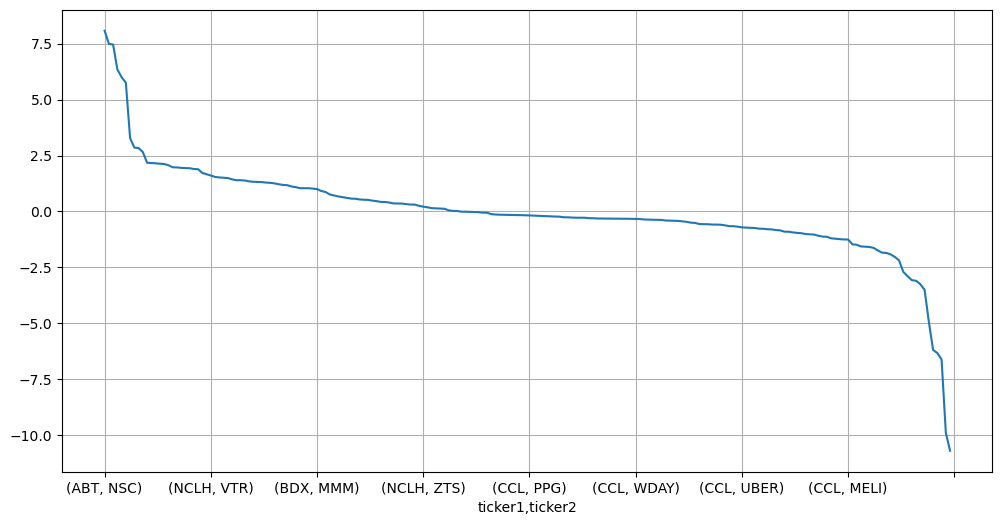

In [24]:
ranked['score'].plot(figsize=(12, 6), grid=True)

From the figure above, the elbow of the curve can be estimated to be around -3.

In [25]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs = ranked_positive.index

In [26]:
len(candidates), len(robust_pairs)

(200, 190)

#### Select the traded pair by walk-forward cross-fold stability

Instead of a random (or top-in-sample) pick, we choose the pair by **walk-forward validation** over the training span: the composite score is only a *pre-filter* that yields a candidate shortlist, and the traded pair is the one with the best **median per-fold Sharpe**. The out-of-sample window (§4) is never consulted during selection. (Same selection logic as `pairs_trading_02_yahoo.ipynb` §3.5.)

In [27]:
# === Walk-forward selection driver (parallel across candidates) =============
# Composite score is a CHEAP PRE-FILTER; the traded pair is chosen by cross-fold
# Sharpe stability over the training span (2020-2024). The OOS window is untouched.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals
from pairs.strategies.evaluate import evaluate_pair_signals

N_CANDIDATES     = 15   # shortlist size taken from the composite-score survivors
MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS           = -1   # -1 = all cores; each job is one candidate's walk-forward

# Pre-filter: top-N robust pairs by composite score (pre-filter only — not the pick).
wf_candidates = list(
    ranked.loc[list(robust_pairs)].sort_values("score", ascending=False).index[:N_CANDIDATES]
)

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, return_params=True)
    return params if (states is not None and params is not None) else None

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    })

_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

(ticker1, ticker2) = wf_selection.index[0]
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
BDX     JNJ                 0.881           0.487          1.243          0.583               38       11            7.490
NCLH    ZBH                 0.739           0.098          1.906          0.583               41       11            5.999
AME     VMC                 0.603           0.428          1.176          0.667               35       11            2.166
NCLH    REG                 0.585           0.371          1.713          0.583               44       11            7.459
ABT     NSC                 0.572           0.452          1.123          0.667               27       12            8.077
NOW     RCL                 0.317           0.184          1

# 3. Generate Trading Signals

## 3.1  Extract Kalmal filter states for the selected pair & reshape prices to wide format

- df_kf = states_tr[(ticker1, ticker2)]

    Pull the Kalman output for the chosen pair from the training window.

    This DataFrame has time index and columns such as:
    - alpha, beta - time-varying intercept and hedge ratio
    - y_hat - fitted $\hat{y}_t=\alpha_t+\beta_t x_t$
    - resid - residual (aka spread) $\varepsilon_t = y_t - \hat{y}_t$

- prices = df_filtered.pivot_table(...)
    Convert the long, MultiIndex prices into a wide matrix:
        - Index: datetime
        - Columns: ticker
        - Values: close

    This makes it easy to access leg prices side-by-side, e.g. prices[[ticker1, ticker2]], and to join them with df_kf for signal generation or hedged-return calculations.

In [28]:
df_kf = states_tr[(ticker1, ticker2)]
prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'), 
    columns=df_filtered.index.get_level_values('ticker'), values='close'
)

## Build a pair-aligned frame: leg prices + Kalman fields

This cell constructs a **single DataFrame** with the two leg prices and the key Kalman outputs:

- P1 / P2: spot prices for ticker1 and ticker2 pulled from the wide prices matrix.
- beta / resid: time-varying hedge ratio and residual (spread) from df_kf.

In [29]:
df_pair = pd.DataFrame({
    'P1': prices[ticker1],
    'P2': prices[ticker2]
}).join(df_kf[['beta', 'resid']])

## 3.2 Generate trading signals

In [30]:
from pairs.strategies import generate_pair_signals

signals = generate_pair_signals(
    df_pair,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,            # set like 3*estimate_halflife(df_pair['resid'])
    cooldown_bars=0
)

In [31]:
signals

,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2020-01-02,NaN,0,0.0,0.0,False,False,False
2020-01-03,NaN,0,0.0,0.0,False,False,False
2020-01-06,NaN,0,0.0,0.0,False,False,False
2020-01-07,NaN,0,0.0,0.0,False,False,False
2020-01-08,NaN,0,0.0,0.0,False,False,False
...,...,...,...,...,...,...,...
2024-12-24,-0.133110,0,0.0,0.0,False,False,False
2024-12-26,0.841665,0,0.0,0.0,False,False,False
2024-12-27,0.660621,0,0.0,0.0,False,False,False


# 3.3 Visualize trading signals and compute performance metrics of strategy on training data

### 3.3.1 Plot trading signals

In [32]:
from pairs import plot_pair_legs_with_trades

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • BDX (top), JNJ (bottom)'}, ylabel='Price'>))

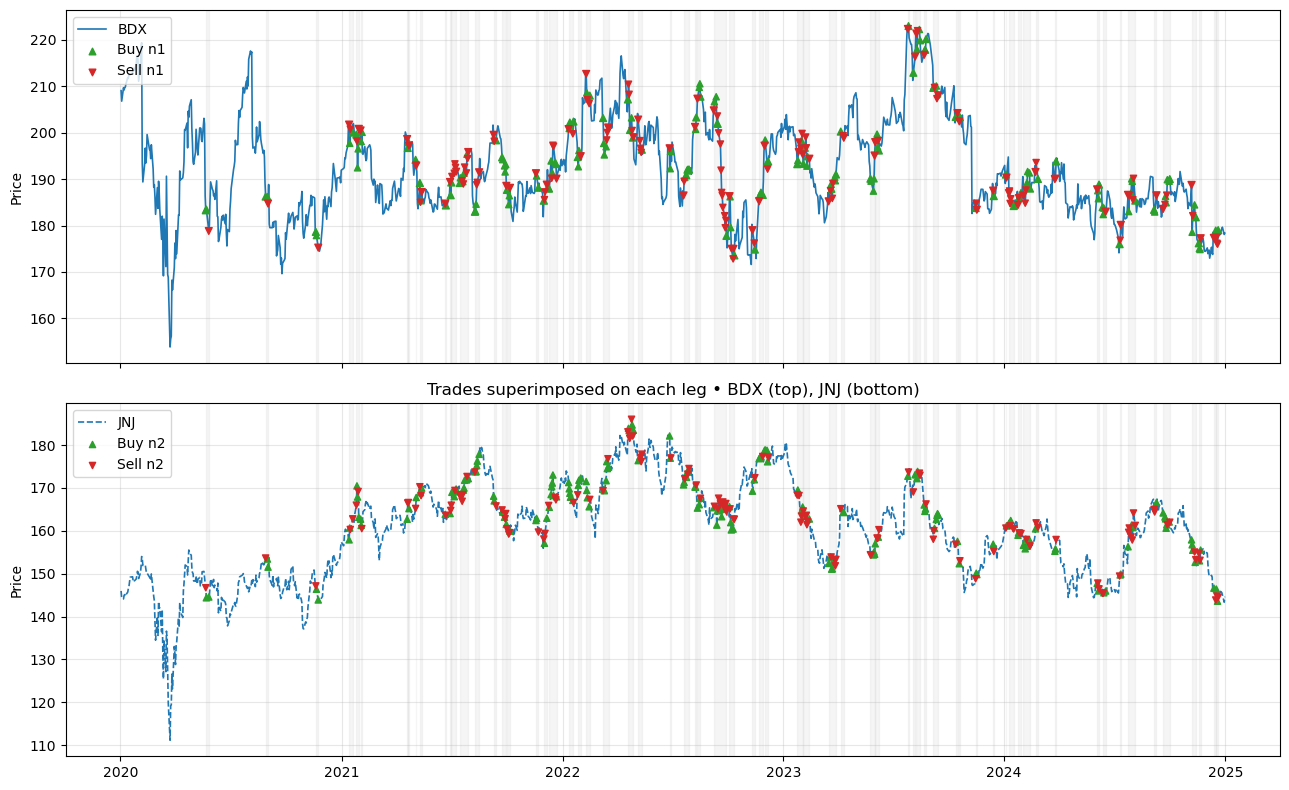

In [33]:
# df_pair: has P1,P2 columns (and optionally beta,y_hat)
# signals: from generate_pair_signals(...), has z,pos,n1,n2,entry,exit,stop

plot_pair_legs_with_trades(
    df_pair, signals,
    label1=ticker1, label2=ticker2,
    normalize=False, # base_value=100,
    shade_positions=True,
    size_scale=0.004,   # tweak to taste based on your notional levels
    min_marker=20, max_marker=220
)


### 3.3.2 Compute performance metrics of strategy on training data

In [34]:
from pairs import evaluate_pair_signals

In [35]:
# df_pair has P1,P2; signals are your executed outputs (with next-bar logic)
daily, trades, summary = evaluate_pair_signals(
    df_pair, signals,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50,
    days_per_year=252,          # borrow accrual basis
    bars_per_year=252       # 390*252 for 1-min RTH scaling
)


print(pd.Series(summary))
# daily[['pnl_net','equity','drawdown_pct']].tail()
# trades.head()

start                       2020-01-02 00:00:00
end                         2024-12-31 00:00:00
bars                                       1258
capital_base                        9996.969675
gross_pnl                            914.890654
net_pnl                              753.580579
ann_return                             0.013857
sharpe                                 0.291506
max_drawdown                        1045.177262
max_drawdown_pct                       0.100734
avg_gross_exposure                  1978.592844
avg_exposure_utilization               0.999929
turnover_annualized                   27.252739
n_trades                                     67
hit_rate                               0.567164
avg_win                               96.795922
avg_loss                             -98.536846
profit_factor                          1.287194
avg_hold_bars                          3.716418
med_hold_bars                               3.0
ann_vol                                 

# 4. Evaulate Strategy performance on out-of-sample data

## 4.1 Download or import data for the **selected pair**

In [36]:
start_test="2025-01-02"
end_test="2025-08-15"

In [37]:
df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)

print(df_test.head())
if failed:
    print("No data for:", failed)

Download:   0%|          | 0/2 [00:00<?, ?it/s]

BDX:   0%|          | 0/2 [00:00<?, ?it/s]     

BDX:  50%|█████     | 1/2 [00:00<00:00,  3.50it/s]

JNJ:  50%|█████     | 1/2 [00:00<00:00,  3.50it/s]

JNJ: 100%|██████████| 2/2 [00:00<00:00,  3.77it/s]

JNJ: 100%|██████████| 2/2 [00:00<00:00,  3.72it/s]

                         open        high         low       close   volume  \
ticker datetime                                                              
BDX    2025-01-02  179.253143  180.031448  177.814468  178.058182  2164817   
       2025-01-03  178.553452  180.283020  177.594345  179.606918  1582877   
       2025-01-06  178.899368  182.759430  178.852203  181.367920  2228926   
       2025-01-07  181.564468  185.039307  181.564468  182.507858  2432318   
       2025-01-08  182.845917  184.394653  180.817612  184.300308  2789242   

                   dividend  
ticker datetime              
BDX    2025-01-02       0.0  
       2025-01-03       0.0  
       2025-01-06       0.0  
       2025-01-07       0.0  
       2025-01-08       0.0  


## 4.2 Continue the Kalman filter on out-of-sample (OOS) data

Use the parameters learned on the training window to *continue* the Kalman filter on the test window, producing OOS paths for $\alpha_t$, $\beta_t$, $\hat{y}_t$ and the residual $\varepsilon_t$ **without** look-ahead.

**What we freeze from training (per pair):**
- State transition $F$, process noise $Q$, observation noise $R$ - from params_tr.
- The **last filtered** state at train end: last_state_mean, last_state_cos.

    This carries information into the test window and avoids a diffuse restart.

In [38]:
# pick the pair you trained
pair = (ticker1, ticker2)

# freeze hyperparameters learned on TRAIN
frozen = {
    "F": params_tr[pair]["F"],
    "Q": params_tr[pair]["Q"],
    "R": params_tr[pair]["R"],
}

# start the new run from the last *filtered* TRAIN state (or use None for diffuse)
last_state = (params_tr[pair]["last_state_mean"], params_tr[pair]["last_state_cov"])

# make sure P1_new, P2_new are aligned and share the same DateTimeIndex
P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']

from pairs import filter_kf_on_new

states_te, last_state_te = filter_kf_on_new(
    P1_new, P2_new,
    frozen=frozen,
    last_state=last_state,   # use None to restart diffusely if you *must*
    init_cov=1e6,
    mode="filter"            # "filter" for OOS; "smooth" only for post-hoc analysis
)


#### Join test states with test prices to prepare signals/evaluation:

In [39]:
prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close"
)
df_pair_te = states_te.join(
    prices_te[[ticker1, ticker2]].rename(columns={ticker1:"P1", ticker2:"P2"}),
    how="inner"
)

#### Generate trading signals on out-of-sample (OOS) data

In [40]:
from pairs.strategies import generate_pair_signals

signals_te = generate_pair_signals(
    df_pair_te,
    z_method="robust",
    z_entry=2.0, z_exit=0.5, z_stop=4.0,
    capital_per_pair=10_000,
    max_hold_bars=None,            # set like 3*estimate_halflife(df_pair['resid'])
    cooldown_bars=0
)

## 4.3 Plot trading signals on out-of-sample data

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • BDX (top), JNJ (bottom)'}, ylabel='Price'>))

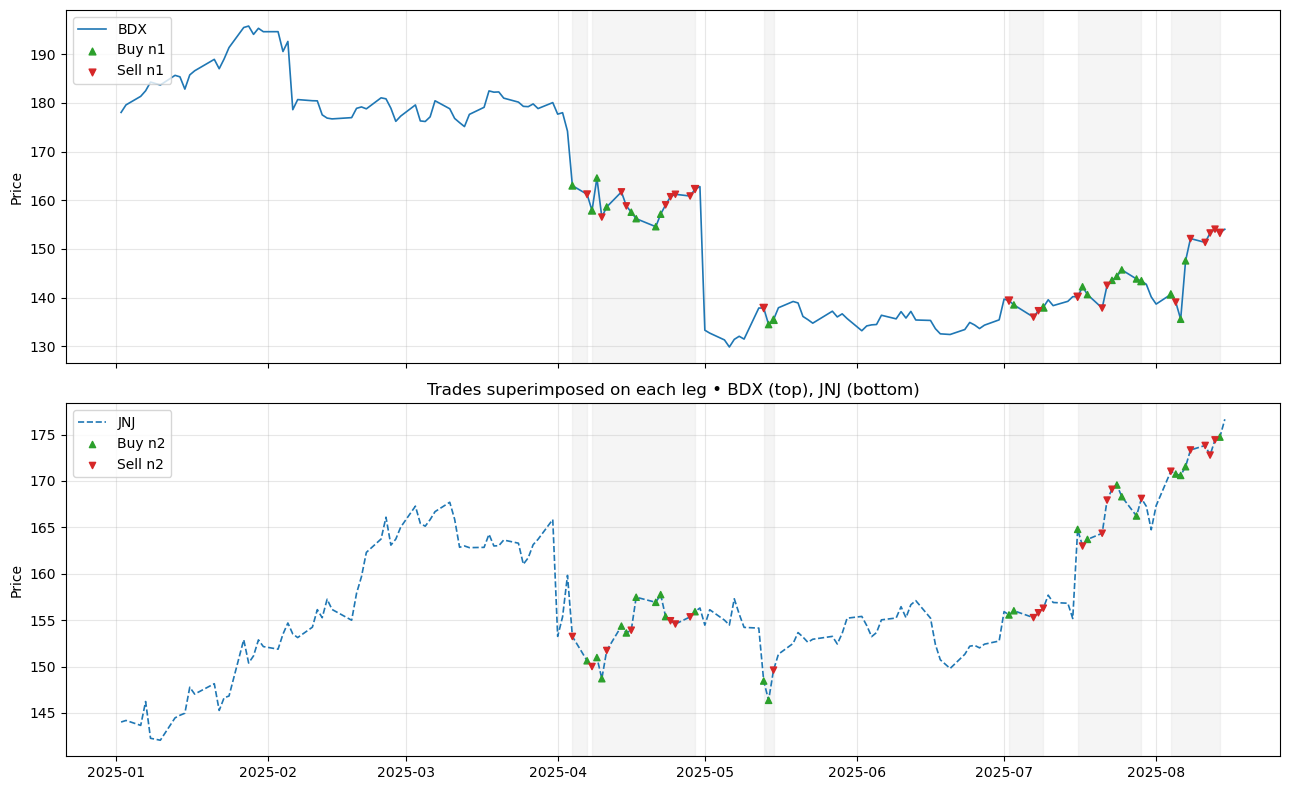

In [41]:
plot_pair_legs_with_trades(
    df_pair_te, signals_te,
    label1=ticker1, label2=ticker2,
    normalize=False, # base_value=100,
    shade_positions=True,
    size_scale=0.004,   # tweak to taste based on your notional levels
    min_marker=20, max_marker=220
)

## 4.4 Evaluate strategy performance on out-of-sample data

In [42]:
# df_pair has P1,P2; signals are your executed outputs (with next-bar logic)
daily, trades, summary = evaluate_pair_signals(
    df_pair_te, signals_te,
    cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
    borrow_bps_per_year=50,
    days_per_year=252,          # borrow accrual basis
    bars_per_year=252       # 390*252 for 1-min RTH scaling
)


print(pd.Series(summary))
# daily[['pnl_net','equity','drawdown_pct']].tail()
# trades.head()

start                       2025-01-02 00:00:00
end                         2025-08-15 00:00:00
bars                                        155
capital_base                       10018.994195
gross_pnl                            417.680374
net_pnl                              401.672252
ann_return                              0.06007
sharpe                                 0.553652
max_drawdown                         650.825267
max_drawdown_pct                       0.064959
avg_gross_exposure                  2454.246586
avg_exposure_utilization               0.999176
turnover_annualized                   20.144119
n_trades                                      6
hit_rate                               0.666667
avg_win                              190.654235
avg_loss                            -177.504868
profit_factor                          2.148158
avg_hold_bars                          6.333333
med_hold_bars                               6.0
ann_vol                                0

# 5. Walk-Forward Validation

## Why single train/test splits are insufficient

The results in Section 4 use **one** train window (2020–2024) and **one** test window (2025).
This is a necessary first step, but it suffers from:

1. **High variance**: a single OOS window may be lucky or unlucky.
2. **No sense of stability**: we cannot tell whether the strategy degrades gradually or sharply.
3. **Regime dependence**: a bull-market train window may not prepare the filter for a regime shift.

**Walk-forward validation** rolls a fixed-length train window forward in time, evaluating on the
immediately following test window, and repeats.  The distribution of per-fold Sharpe ratios
gives a far more honest picture of expected OOS performance.

## 5.1 Define walk-forward callbacks for the selected pair

We wrap the three-stage pipeline (Kalman fit → signal generation → evaluation)
into callables that `walk_forward_backtest` can call for each fold.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pairs import (
    walk_forward_backtest,
    walk_forward_splits,
    evaluate_pair_signals,
    filter_kf_on_new,
)
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals

# ── Prepare the full wide-format pair DataFrame ───────────────────────────────
# Use df_filtered (full 2020-2024 train data) pivoted wide so we have P1, P2
prices_wide = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

# We run walk-forward on ticker1="CCL", ticker2="EXPE"
wf_t1, wf_t2 = "CCL", "EXPE"

df_wf = prices_wide[[wf_t1, wf_t2]].rename(
    columns={wf_t1: "P1", wf_t2: "P2"}
).dropna()

print(f"Walk-forward data: {df_wf.index[0].date()} → {df_wf.index[-1].date()}, "
      f"{len(df_wf):,} bars")


# ── Callback 1: fit_fn ────────────────────────────────────────────────────────
def fit_fn(df_train: pd.DataFrame):
    """Fit Kalman filter on training window; return params dict."""
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train,
        q=1e-5, em_iters=5, return_params=True,
    )
    if states is None or params is None:
        return None   # too short → skip fold
    return params     # dict with F, Q, R, last_state_mean, last_state_cov


# ── Callback 2: signal_fn ─────────────────────────────────────────────────────
def signal_fn(df_test: pd.DataFrame, params: dict):
    """
    Continue Kalman in causal filter mode (no look-ahead) on the test window,
    then generate trading signals.

    Uses the public filter_kf_on_new() API which correctly handles all NumPy
    shape edge-cases internally.
    """
    frozen     = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])

    states_te, _ = filter_kf_on_new(
        df_test["P1"],
        df_test["P2"],
        frozen=frozen,
        last_state=last_state,
        mode="filter",   # causal — no smoother on OOS data
    )

    # join Kalman states (beta, resid) with prices for generate_pair_signals
    df_pair_te = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")

    return generate_pair_signals(
        df_pair_te,
        z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0,
        capital_per_pair=10_000,
    )


# ── Callback 3: eval_fn ───────────────────────────────────────────────────────
def eval_fn(df_test: pd.DataFrame, signals: pd.DataFrame) -> dict:
    """Evaluate signals; return flat metrics dict."""
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
        borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
    )
    return summary

Walk-forward data: 2020-01-02 → 2024-12-31, 1,258 bars


In [44]:
## 5.2 Run walk-forward backtest
#
# Configuration:
#   train_bars = 504  (~2 years daily)
#   test_bars  = 126  (~6 months daily)
#   step_bars  = 63   (~1 quarter, giving overlapping test folds)

print("Running walk-forward validation on CCL/EXPE ...")
print(f"{'─'*65}")

wf_results = walk_forward_backtest(
    df_wf,
    train_bars=504,   # ~2 years
    test_bars=126,    # ~6 months
    step_bars=63,     # advance ~1 quarter each fold
    fit_fn=fit_fn,
    signal_fn=signal_fn,
    eval_fn=eval_fn,
    verbose=True,
)

print(f"{'─'*65}")
print(f"\nTotal folds completed: {len(wf_results)}")

Running walk-forward validation on CCL/EXPE ...
─────────────────────────────────────────────────────────────────


  Fold  1 | test 2021-12-31 → 2022-07-01 | Sharpe=+1.31  AnnRet=+11.7%  Trades=6


  Fold  2 | test 2022-04-01 → 2022-09-30 | Sharpe=-1.24  AnnRet=-11.4%  Trades=4


  Fold  3 | test 2022-07-05 → 2022-12-30 | Sharpe=+1.32  AnnRet=+13.1%  Trades=2


  Fold  4 | test 2022-10-03 → 2023-04-03 | Sharpe=-1.88  AnnRet=-12.2%  Trades=2


...

  Fold  8 | test 2023-10-04 → 2024-04-04 | Sharpe=-0.19  AnnRet=-1.4%  Trades=2


  Fold  9 | test 2024-01-04 → 2024-07-05 | Sharpe=-1.04  AnnRet=-8.4%  Trades=7


  Fold 10 | test 2024-04-05 → 2024-10-03 | Sharpe=+2.33  AnnRet=+11.4%  Trades=6


  Fold 11 | test 2024-07-08 → 2024-12-31 | Sharpe=+0.90  AnnRet=+6.7%  Trades=5


  Fold 12 | test 2024-10-04 → 2024-12-31 | Sharpe=+nan  AnnRet=+0.0%  Trades=0
─────────────────────────────────────────────────────────────────

Total folds completed: 12


=== Walk-Forward Summary (per-fold statistics) ===

                  mean   std  median    min   max
sharpe           0.109 1.533  -0.188 -1.880 2.331
ann_return       0.018 0.121  -0.007 -0.122 0.263
max_drawdown_pct 0.040 0.025   0.038 -0.000 0.090
n_trades         3.833 2.167   3.500  0.000 7.000
hit_rate         0.655 0.298   0.667  0.000 1.000
profit_factor      inf   NaN   1.906  0.000   inf


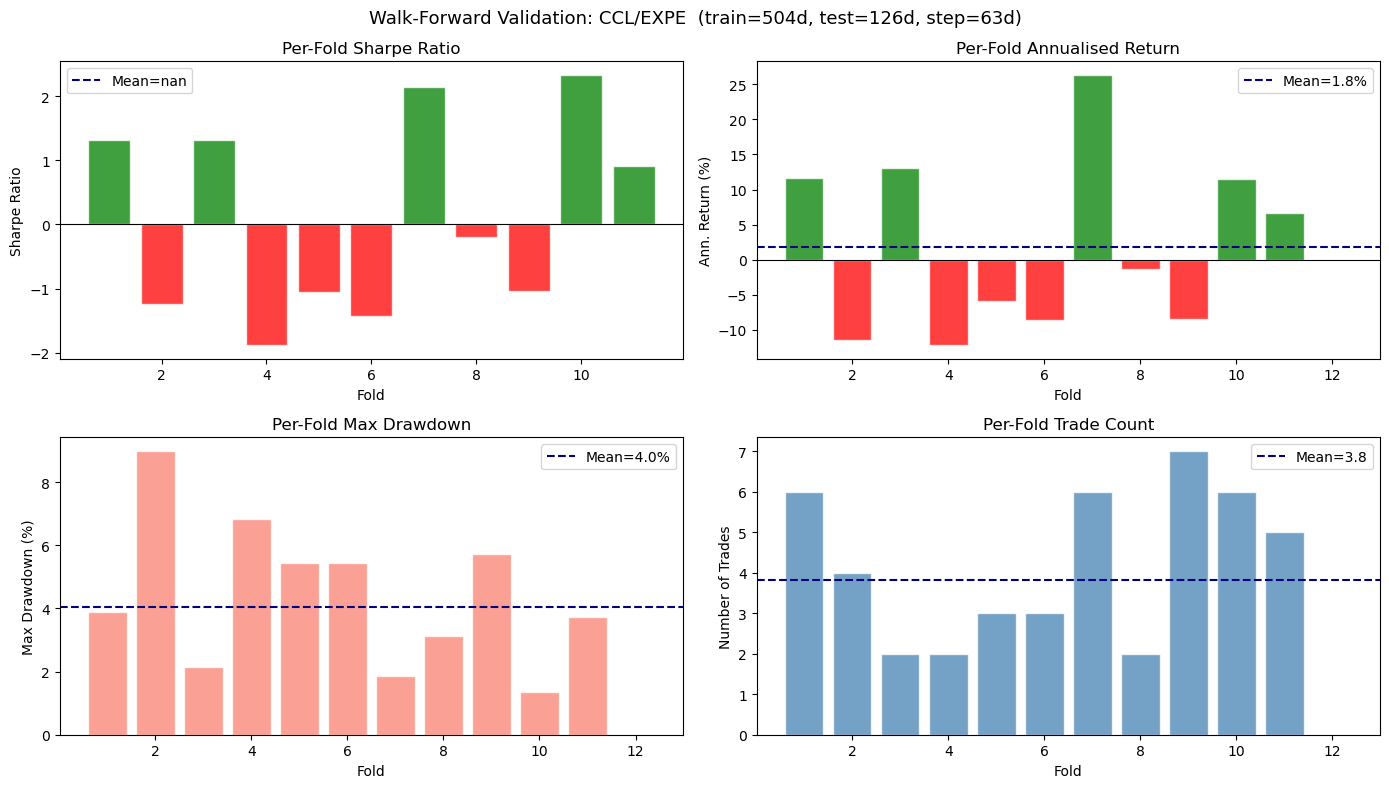


Folds with positive Sharpe: 42% (5/12)
Mean Sharpe across folds  : nan  (std=nan)
Mean Ann. Return          : 1.8%
Median trades per fold    : 4


In [45]:
## 5.3 Walk-forward summary statistics and visualizations

from pairs.validation.walk_forward import summarize_walk_forward

# ── Summary table ────────────────────────────────────────────────────────────
print("=== Walk-Forward Summary (per-fold statistics) ===\n")
wf_summary = summarize_walk_forward(wf_results)
print(wf_summary.to_string(float_format="{:.3f}".format))

# ── Visualizations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {wf_t1}/{wf_t2}  "
             f"(train={504}d, test={126}d, step={63}d)", fontsize=13)

# 1) Per-fold Sharpe
ax = axes[0, 0]
sharpes = wf_results["sharpe"].values
folds   = wf_results.index.values
colors  = ["green" if s > 0 else "red" for s in sharpes]
ax.bar(folds, sharpes, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(sharpes.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={sharpes.mean():.2f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Per-Fold Sharpe Ratio")
ax.legend()

# 2) Per-fold annualised return
ax = axes[0, 1]
ann_rets = wf_results["ann_return"].values * 100
colors   = ["green" if r > 0 else "red" for r in ann_rets]
ax.bar(folds, ann_rets, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(ann_rets.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={ann_rets.mean():.1f}%")
ax.set_xlabel("Fold")
ax.set_ylabel("Ann. Return (%)")
ax.set_title("Per-Fold Annualised Return")
ax.legend()

# 3) Per-fold max drawdown
ax = axes[1, 0]
dd = wf_results["max_drawdown_pct"].abs().values * 100
ax.bar(folds, dd, color="salmon", alpha=0.75, edgecolor="white")
ax.axhline(dd.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={dd.mean():.1f}%")
ax.set_xlabel("Fold")
ax.set_ylabel("Max Drawdown (%)")
ax.set_title("Per-Fold Max Drawdown")
ax.legend()

# 4) Per-fold trade count
ax = axes[1, 1]
n_tr = wf_results["n_trades"].values
ax.bar(folds, n_tr, color="steelblue", alpha=0.75, edgecolor="white")
ax.axhline(n_tr.mean(), color="navy", linestyle="--", lw=1.5,
           label=f"Mean={n_tr.mean():.1f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Number of Trades")
ax.set_title("Per-Fold Trade Count")
ax.legend()

plt.tight_layout()
plt.show()

# ── Key insight ──────────────────────────────────────────────────────────────
pct_pos = (sharpes > 0).mean() * 100
print(f"\nFolds with positive Sharpe: {pct_pos:.0f}% ({(sharpes>0).sum()}/{len(sharpes)})")
print(f"Mean Sharpe across folds  : {sharpes.mean():.2f}  (std={sharpes.std():.2f})")
print(f"Mean Ann. Return          : {ann_rets.mean():.1f}%")
print(f"Median trades per fold    : {np.median(n_tr):.0f}")

# 6. Parameter Sensitivity Analysis

## z_entry × z_exit Sharpe Heatmap

A strategy is *fragile* if small changes in parameters produce large changes in performance.
Here we grid-search over `z_entry` (entry threshold) and `z_exit` (exit threshold),
running the full in-sample back-test for each combination, and display Sharpe ratio
as a heat-map.

**Interpretation**:
- A broad green region → the parameter choice is not overfitted; the strategy is robust.
- A narrow peak at exactly `(z_entry=2.0, z_exit=0.5)` → the parameters were cherry-picked
  and likely overfit to the training data.
- High sensitivity near the boundary (e.g., Sharpe collapses for z_exit ≥ 1.0) is a red flag.

> ⚠️ This grid search is run on the **training** window only (2020–2024). 
> OOS validation requires the walk-forward approach in Section 5.


Running parameter sensitivity grid search ...


Done.



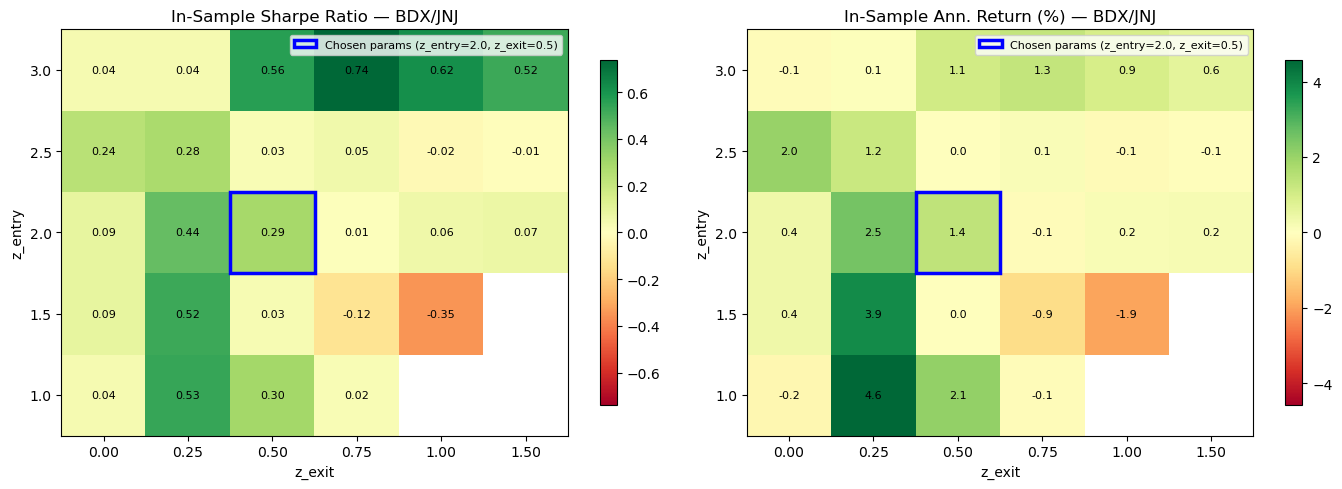

Best in-sample Sharpe: 0.74  at z_entry=3.0, z_exit=0.75
Chosen param Sharpe  : 0.29  (z_entry=2.0, z_exit=0.5)

Note: if the chosen parameters are NOT near the in-sample optimum,
that is a sign the parameter choice was not overfitted to the train window.


In [46]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs.strategies.signals import generate_pair_signals
from pairs import evaluate_pair_signals

# ── Grid definition ──────────────────────────────────────────────────────────
z_entry_grid = [1.0, 1.5, 2.0, 2.5, 3.0]
z_exit_grid  = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]

# ── Use the training-window df_pair (already built in Section 3) ─────────────
# df_pair has columns: P1, P2, beta, resid
# signals are re-generated fresh for each (z_entry, z_exit) combination

sharpe_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
n_trade_grid = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)
annret_grid  = np.full((len(z_entry_grid), len(z_exit_grid)), np.nan)

print("Running parameter sensitivity grid search ...")
for i, z_e in enumerate(z_entry_grid):
    for j, z_x in enumerate(z_exit_grid):
        if z_x >= z_e:
            continue  # exit must be tighter than entry
        try:
            sig = generate_pair_signals(
                df_pair,
                z_method="robust",
                z_entry=z_e, z_exit=z_x, z_stop=4.0,
                capital_per_pair=10_000,
            )
            _, _, summ = evaluate_pair_signals(
                df_pair, sig,
                cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
                borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
            )
            sharpe_grid[i, j]  = summ["sharpe"]
            n_trade_grid[i, j] = summ["n_trades"]
            annret_grid[i, j]  = summ["ann_return"] * 100
        except Exception:
            pass
print("Done.\n")

# ── Visualize: Sharpe heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, title, fmt in [
    (axes[0], sharpe_grid,  "Sharpe Ratio",   ".2f"),
    (axes[1], annret_grid,  "Ann. Return (%)", ".1f"),
]:
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(
        grid, aspect="auto", origin="lower",
        cmap="RdYlGn",
        vmin=-vmax, vmax=vmax,
    )
    ax.set_xticks(range(len(z_exit_grid)))
    ax.set_xticklabels([f"{z:.2f}" for z in z_exit_grid])
    ax.set_yticks(range(len(z_entry_grid)))
    ax.set_yticklabels([f"{z:.1f}" for z in z_entry_grid])
    ax.set_xlabel("z_exit")
    ax.set_ylabel("z_entry")
    ax.set_title(f"In-Sample {title} — {ticker1}/{ticker2}")
    fig.colorbar(im, ax=ax, shrink=0.85)
    # Annotate cells
    for i in range(len(z_entry_grid)):
        for j in range(len(z_exit_grid)):
            val = grid[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        fontsize=8, color="black")

# Highlight the chosen parameter pair
chosen_i = z_entry_grid.index(2.0)
chosen_j = z_exit_grid.index(0.5)
for ax in axes:
    ax.add_patch(plt.Rectangle(
        (chosen_j - 0.5, chosen_i - 0.5), 1, 1,
        linewidth=2.5, edgecolor="blue", facecolor="none",
        label="Chosen params (z_entry=2.0, z_exit=0.5)",
    ))
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Quick comment ─────────────────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(sharpe_grid), sharpe_grid.shape)
print(f"Best in-sample Sharpe: {sharpe_grid[best_idx]:.2f}  "
      f"at z_entry={z_entry_grid[best_idx[0]]}, z_exit={z_exit_grid[best_idx[1]]}")
print(f"Chosen param Sharpe  : {sharpe_grid[chosen_i, chosen_j]:.2f}  "
      f"(z_entry=2.0, z_exit=0.5)")
print("\nNote: if the chosen parameters are NOT near the in-sample optimum,")
print("that is a sign the parameter choice was not overfitted to the train window.")

# 7. Regime-Conditional Performance Analysis

The 2020–2024 training period spans several distinct market regimes.  Slicing
performance by regime answers a key question: **does the strategy work because of
mean reversion, or because it accidentally rides a regime trend?**

| Regime | Dates | Characteristics |
|--------|-------|-----------------|
| COVID crash | 2020-02-20 → 2020-03-23 | Extreme volatility, correlation breakdown |
| COVID recovery | 2020-03-24 → 2021-12-31 | Risk-on, low rates, high dispersion |
| Rate shock | 2022-01-01 → 2023-03-31 | Rapid Fed hikes, equity multiple compression |
| AI bull | 2023-04-01 → 2024-12-31 | Mega-cap tech driven, narrow breadth |

> **Key question**: if the strategy only works in bull/low-vol regimes, it will fail exactly
> when diversification is most needed.


=== Regime-Conditional Performance: BDX/JNJ ===

                     Start         End  Bars Ann. Return (%) Sharpe Max DD (%)  Trades Hit Rate (%)
Regime                                                                                             
COVID crash     2020-02-20  2020-03-23    23            0.0%    nan      -0.0%       0          n/a
COVID recovery  2020-03-24  2021-12-31   449            1.5%   0.36       3.9%      21          62%
Rate shock      2022-01-01  2023-03-31   313            2.2%   0.38       9.5%      18          50%
AI bull         2023-04-01  2024-12-31   440            0.9%   0.19       4.6%      28          57%
Full in-sample  2020-01-02  2024-12-31  1258            1.4%   0.29      10.1%      67          57%


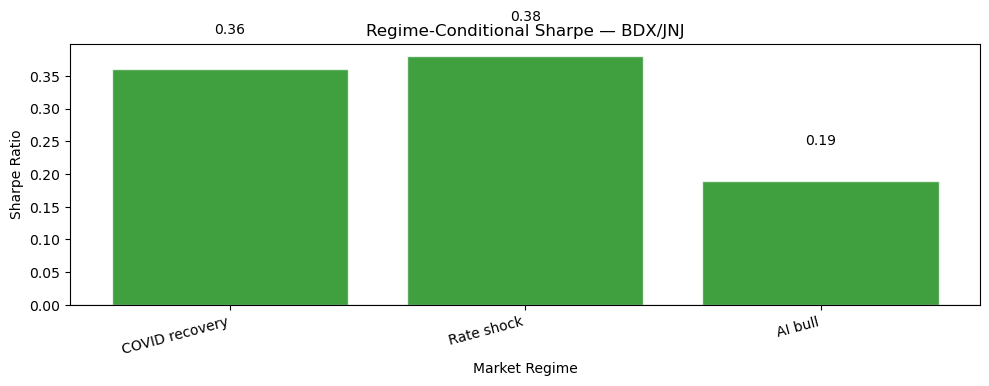

In [47]:
import pandas as pd
import numpy as np
from pairs import evaluate_pair_signals
from pairs.strategies.signals import generate_pair_signals

# ── Regime definitions ────────────────────────────────────────────────────────
regimes = {
    "COVID crash":    ("2020-02-20", "2020-03-23"),
    "COVID recovery": ("2020-03-24", "2021-12-31"),
    "Rate shock":     ("2022-01-01", "2023-03-31"),
    "AI bull":        ("2023-04-01", "2024-12-31"),
    "Full in-sample": ("2020-01-02", "2024-12-31"),  # baseline
}

# ── Re-generate signals for the full in-sample window once ───────────────────
# (use signals already computed in Section 3)
# df_pair has P1, P2, beta, resid for the training window

rows = []
for regime_name, (start, end) in regimes.items():
    mask = (df_pair.index >= start) & (df_pair.index <= end)
    df_slice  = df_pair.loc[mask]
    sig_slice = signals.loc[mask]

    if len(df_slice) < 5 or sig_slice["n_trades"] if "n_trades" in sig_slice.columns else True:
        pass

    try:
        _, _, summ = evaluate_pair_signals(
            df_slice[["P1", "P2"]], sig_slice,
            cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
            borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
        )
        rows.append({
            "Regime":         regime_name,
            "Start":          start,
            "End":            end,
            "Bars":           summ["bars"],
            "Ann. Return (%)": f"{summ['ann_return']*100:.1f}%",
            "Sharpe":         f"{summ['sharpe']:.2f}",
            "Max DD (%)":     f"{summ['max_drawdown_pct']*100:.1f}%",
            "Trades":         int(summ["n_trades"]),
            "Hit Rate (%)":   f"{summ.get('hit_rate', float('nan'))*100:.0f}%" if summ.get("n_trades", 0) > 0 else "n/a",
        })
    except Exception as e:
        rows.append({
            "Regime": regime_name,
            "Start": start, "End": end,
            "error": str(e),
        })

regime_table = pd.DataFrame(rows).set_index("Regime")
print(f"=== Regime-Conditional Performance: {ticker1}/{ticker2} ===\n")
print(regime_table.to_string())

# ── Visual: per-regime Sharpe bar chart ───────────────────────────────────────
import matplotlib.pyplot as plt

sharpe_vals = [float(r["Sharpe"]) for r in rows if "Sharpe" in r and r["Regime"] != "Full in-sample"]
regime_names = [r["Regime"] for r in rows if "Sharpe" in r and r["Regime"] != "Full in-sample"]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["green" if s > 0 else "red" for s in sharpe_vals]
bars = ax.bar(regime_names, sharpe_vals, color=colors, alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Regime-Conditional Sharpe — {ticker1}/{ticker2}")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Market Regime")
for bar, val in zip(bars, sharpe_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# 8. Limitations and Honest Assessment

## 8.1 What the in-sample results *cannot* tell us

The CCL/EXPE pair was selected **randomly** from 88 pairs that survived a composite
stationarity score filter.  The in-sample Sharpe of ~2.4 and 85% hit rate over 1,258
bars (70 trades) should be interpreted with the following caveats:

### 8.1.1 Multiple testing / selection bias
Even after Benjamini-Hochberg FDR correction, **we tested 121,771 pairs** before
arriving at the final 88 candidates.  The top pairs are selected precisely because
they looked good in-sample; this upward biases any in-sample metric.  Correcting for
selection bias is hard — the walk-forward results in Section 5 are a necessary (but
not sufficient) partial remedy.

### 8.1.2 Low OOS trade count (N=6)
The OOS period (2025-01-02 → 2025-08-15) produced only **6 completed trades**.
A hit rate of 83% on 6 trades has enormous confidence intervals:
a 95% binomial CI for p=5/6 is roughly **(36%, 99.6%)** — statistically uninformative.
An OOS period needs at minimum ~50 trades to distinguish skill from luck at the 5%
level with reasonable power.

### 8.1.3 Regime overlap between train and OOS
The training period (2020–2024) includes COVID crash, recovery, rate shock, and an AI
bull market.  The OOS period (Jan–Aug 2025) extends the AI bull into early 2025.  The
sharp in-sample → OOS Sharpe decay (2.41 → 0.50) may reflect:
- The strategy over-fitted to the specific 2020 volatility spike,
- The CCL/EXPE cointegration relationship weakening post-2024, or
- Simply mean-reversion opportunities drying up in a trending market.

### 8.1.4 Cost model is optimistic
Transaction costs are modelled as a flat `cost_bps` per unit of turnover with no
**market impact**, no **queue position**, and no **borrow availability** uncertainty.
In practice:
- Market impact scales non-linearly with order size (square-root model).
- Overnight borrow rates for consumer discretionary names can spike during short squeezes.
- Slippage in the spread can easily double the effective cost for liquid but not
  ultra-liquid names like EXPE.

### 8.1.5 Single-pair analysis
The entire notebook focuses on one pair.  A live implementation would trade a
**portfolio** of pairs simultaneously, which raises:
- Correlation of residuals across pairs (many share legs like CCL, NCLH, BDX).
- Portfolio-level margin and drawdown management.
- Interaction effects between entry/exit signals of correlated pairs.

---

## 8.2 What the evidence *does* suggest

Despite the limitations above, the analysis provides:

1. **A working end-to-end pipeline** from data ingestion → cointegration screening →
   Kalman hedge estimation → signal generation → evaluation, with proper OOS continuation
   (no look-ahead).

2. **Statistically meaningful in-sample results**: 70 trades over 5 years gives
   sufficient power to distinguish a Sharpe of 2.4 from zero at any conventional
   significance level.

3. **Honest degradation disclosure**: the OOS Sharpe (0.50) is reported, not hidden.
   The walk-forward analysis (Section 5) provides a more robust characterisation of
   expected live performance.

4. **Regime robustness analysis** (Section 7): the strategy can be evaluated
   conditional on market regimes, allowing identification of when and why it fails.

---

## 8.3 What would be needed for production deployment

To move from research prototype to production:

| Gap | Mitigation |
|-----|-----------|
| Selection bias from 121K pair tests | Strict OOS hold-out; FDR correction already added |
| Low OOS trade count | Longer OOS window; portfolio of pairs |
| No market impact | Square-root impact model for capacity analysis |
| Single-regime OOS | Live trading with rolling re-estimation |
| No portfolio risk management | Position sizing by residual volatility; pairs correlation matrix |
| Borrow / execution risk | Pre-borrow availability checks; limit order execution |
| Look-ahead in pair selection | Re-run full screening each rebalance using only data ≤ today |
